In [124]:
%pip install yfinance scikit-learn hmmlearn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [125]:
import yfinance as yf
import pandas as pd
import numpy as np
import joblib

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from pathlib import Path

import matplotlib.pyplot as plt

In [126]:
# ROOT = Path(__file__).resolve().parents[2]

ROOT = Path.cwd().parent
print(ROOT)


/home/shubham/Documents/projects/iitisoc-hmm-market-regimes


In [ ]:
# NIFTY
data = yf.download(
    "^NSEI",
    start= "2010-01-01",
    end= "2026-01-01",
    auto_adjust=True
)

# # S&P 500
# data = yf.download(
#     "SPY",
#     start= "2010-01-01",
#     end= "2026-01-01",
#     auto_adjust=True
# )

print(data.head())
# print(data.columns)
print(data.shape)

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker         BTC-USD     BTC-USD     BTC-USD     BTC-USD   BTC-USD
Date                                                                
2014-09-17  457.334015  468.174011  452.421997  465.864014  21056800
2014-09-18  424.440002  456.859985  413.104004  456.859985  34483200
2014-09-19  394.795990  427.834991  384.532013  424.102997  37919700
2014-09-20  408.903992  423.295990  389.882996  394.673004  36863600
2014-09-21  398.821014  412.425995  393.181000  408.084991  26580100
(4124, 5)


In [128]:
data

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100
...,...,...,...,...,...
2025-12-27,87802.156250,87874.781250,87182.976562,87301.429688,13741199310
2025-12-28,87835.835938,87986.890625,87394.953125,87799.343750,15156557929


In [129]:
# Flatten MultiIndex columns
data.columns = data.columns.get_level_values(0)
# Convert Date index to normal column
data = data.reset_index()
# Remove column index name
data.columns.name = None
# Sort by date
data = data.sort_values("Date").reset_index(drop=True)
# Save clean dataset
data.to_csv(
    ROOT / "data" / "clean_data.csv"
)
print(data.columns)
print(data.shape)

data.head()

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
(4124, 6)


,Date,Close,High,Low,Open,Volume
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [130]:

# Calculate log returns
data["Log_Return"] = np.log(
    data["Close"] / data["Close"].shift(1)
)
# garman-klass volatility
data["gk_volatility"] = np.sqrt(0.5*(np.log(data["High"]/data["Low"]))**2
    -(2*np.log(2)-1) * (np.log(data["Close"]/data["Open"]))**2)
# Range Feature
data["Range"] = (
    data["High"] - data["Low"]
) / data["Close"]
# Remove NaN values created by rolling window
data = data.dropna().reset_index(drop=True)


In [131]:
features = data[[
    "Date",
    "Log_Return",
    "gk_volatility",
    "Range"
]].copy()
print(features.head())
print(features.shape)

        Date  Log_Return  gk_volatility     Range
0 2014-09-18   -0.074643       0.054544  0.103091
1 2014-09-19   -0.072402       0.060933  0.109684
2 2014-09-20    0.035111       0.053812  0.081714
3 2014-09-21   -0.024968       0.030628  0.048255
4 2014-09-22    0.008317       0.016549  0.024334
(4123, 4)


In [132]:

X = features[["Log_Return", "gk_volatility","Range"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])
print(X_scaled.shape)


[[-2.14402052  1.38049425  1.64881297]
 [-2.08070777  1.68585688  1.83035675]
 [ 0.95560102  1.34550159  1.06019621]
 [-0.7411102   0.23733396  0.13892916]
 [ 0.19890637 -0.43564057 -0.51971132]]
(4123, 3)


In [133]:

hmm_model = GaussianHMM(
    n_components=5,
    covariance_type="full",
    n_iter=100,
    random_state=42
)

hmm_model.fit(X_scaled)
log_likelihood = hmm_model.score(X_scaled)
print("Training completed")
print("Number of states:", hmm_model.n_components)
print("Log Likelihood:", log_likelihood)


Training completed
Number of states: 5
Log Likelihood: 271.6529235045983


In [134]:


joblib.dump(
    hmm_model,
    "hmm_model.pkl"
)

['hmm_model.pkl']

In [135]:
print("State Means:")
print(hmm_model.means_)
print("\nTransition Matrix:")
print(hmm_model.transmat_)


State Means:
[[ 0.4113439  -0.45032446 -0.44894131]
 [-0.67229327 -0.16619076 -0.14114539]
 [-1.27169369  1.70580072  1.7075365 ]
 [ 1.28719315  0.4558009   0.58944959]
 [-0.07077755 -0.41700996 -0.52051123]]

Transition Matrix:
[[0.26230586 0.28074527 0.03680546 0.11082182 0.30932159]
 [0.27864813 0.22253712 0.081501   0.13473215 0.28258161]
 [0.10626553 0.09681915 0.39279746 0.29650917 0.1076087 ]
 [0.10841485 0.21545089 0.15073389 0.25152291 0.27387746]
 [0.29963342 0.23888575 0.0471048  0.12639144 0.28798458]]


In [136]:
features.to_csv(
    ROOT / "data" / "features.csv",
    index=False
)

print("features.csv saved")

features.csv saved


In [137]:
states = hmm_model.predict(X_scaled)

features["State"] = states

print("\nState Counts:")
print(features["State"].value_counts())

print("\nState Statistics:")
print(
    features.groupby("State")[
        ["Log_Return", "gk_volatility", "Range"]
    ].mean()
)

states_df = features[
    ["Date", "State"]
].copy()


State Counts:
State
4    1173
0     968
1     913
3     643
2     426
Name: count, dtype: int64

State Statistics:
       Log_Return  gk_volatility     Range
State                                     
0        0.016355       0.016591  0.027545
1       -0.022987       0.022442  0.038615
2       -0.045233       0.062378  0.107097
3        0.048267       0.035957  0.066169
4       -0.001157       0.016681  0.023923


In [138]:
states_df.to_csv(
    ROOT /"data" / "states.csv",
    index=False
)
print("states.csv saved successfully")

states.csv saved successfully


In [139]:
state_probs = hmm_model.predict_proba(
    X_scaled
)
prob_df = pd.DataFrame(
    state_probs,
    columns=[
        f"State_{i}"
        for i in range(
            hmm_model.n_components
        )
    ]
)
prob_df["Date"] = features["Date"]
prob_df.to_csv(
    ROOT / "data" / "state_probabilities.csv",
    index=False
)
print("state_probabilities.csv saved")

state_probabilities.csv saved


In [140]:
transition_df = pd.DataFrame(
    hmm_model.transmat_
)

transition_df.to_csv(
    ROOT / "data" / "transition_matrix.csv",
    index=False
)
print("transition_matrix.csv saved")

transition_matrix.csv saved


In [141]:
import numpy as np

stats = []

# features["GK_Volatility"] = np.sqrt(
#     0.5 * (np.log(features["High"] / features["Low"])) ** 2
#     - (2 * np.log(2) - 1)
#     * (np.log(features["Close"] / features["Open"])) ** 2
# )

for state in range(
    hmm_model.n_components
):

    state_data = features[
        features["State"] == state
    ]

    mean_return = (
        state_data["Log_Return"]
        .mean()
    )

    gk_volatility = state_data["gk_volatility"].mean()

    sharpe = (
        mean_return /
        gk_volatility
        if gk_volatility > 0
        else np.nan
    )

    downside = state_data[
        state_data["Log_Return"] < 0
    ]["Log_Return"]

    sortino = (
        mean_return /
        downside.std()
        if len(downside) > 1
        else np.nan
    )

    stats.append({
        "State": state,
        "Frequency": len(state_data),
        "Mean_Return": mean_return,
        "gk_Volatility": gk_volatility,
        "Sharpe_Ratio": sharpe,
        "Sortino_Ratio": sortino
    })

state_characteristics = pd.DataFrame(
    stats
)
state_characteristics.to_csv(
    ROOT / "data" / "state_characteristics.csv",
    index=False
)
state_characteristics

,State,Frequency,Mean_Return,gk_Volatility,Sharpe_Ratio,Sortino_Ratio
0,0,968,0.016355,0.016591,0.985828,NaN
1,1,913,-0.022987,0.022442,-1.024300,-1.826258
2,2,426,-0.045233,0.062378,-0.725144,-1.003274
3,3,643,0.048267,0.035957,1.342357,NaN
4,4,1173,-0.001157,0.016681,-0.069353,-0.391219


In [142]:
persistence = []

for i in range(
    hmm_model.n_components
):

    pii = hmm_model.transmat_[i, i]

    persistence.append({
        "State": i,
        "Persistence": pii,
        "Expected_Duration":
            1/(1-pii)
    })

persistence_df = pd.DataFrame(
    persistence
)

persistence_df.to_csv(
    ROOT / "data" / "persistence_metrics.csv",
    index=False
)
persistence_df

,State,Persistence,Expected_Duration
0,0,0.262306,1.355575
1,1,0.222537,1.286235
2,2,0.392797,1.646897
3,3,0.251523,1.336046
4,4,0.287985,1.404464


In [143]:
import joblib
joblib.dump(
    hmm_model,
    "hmm_model.pkl"
)
joblib.dump(
    scaler,
    "scaler.pkl"
)
print("Model and scaler saved")

Model and scaler saved


In [144]:
plot_data = data.copy()

plot_data = plot_data.iloc[-len(states):].copy()

plot_data["State"] = states

plot_data.head()

,Date,Close,High,Low,Open,Volume,Log_Return,gk_volatility,Range,State
0,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,-0.074643,0.054544,0.103091,2
1,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,-0.072402,0.060933,0.109684,2
2,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,0.035111,0.053812,0.081714,3
3,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,-0.024968,0.030628,0.048255,1
4,2014-09-22,402.152008,406.915985,397.130005,399.100006,24127600,0.008317,0.016549,0.024334,0


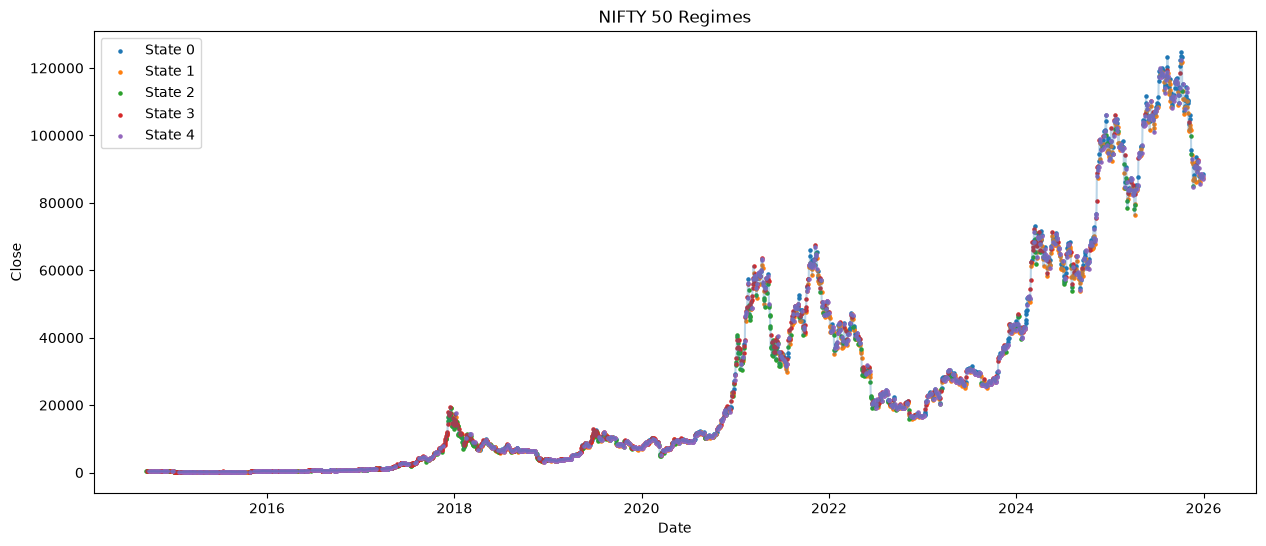

<Figure size 640x480 with 0 Axes>

In [145]:


plt.figure(figsize=(15,6))

for state in sorted(plot_data["State"].unique()):
    mask = plot_data["State"] == state

    plt.scatter(
        plot_data.loc[mask, "Date"],
        plot_data.loc[mask, "Close"],
        s=5,
        label=f"State {state}"
    )

plt.plot(
    plot_data["Date"],
    plot_data["Close"],
    alpha=0.3
)

plt.title("NIFTY 50 Regimes")
plt.xlabel("Date")
plt.ylabel("Close")
plt.legend()
plt.show()
plt.savefig(
    ROOT / "data" / "plot.png",
    dpi=300,
    bbox_inches="tight"
)

In [146]:
import os

print(os.getcwd())
print(os.listdir())

/home/shubham/Documents/projects/iitisoc-hmm-market-regimes/notebooks
['.gitkeep', 'tempCodeRunnerFile.ipynb', 'backtesting_analysis.ipynb', 'base_hmm_model.ipynb', 'best_state.ipynb', 'hmm_model.pkl', 'scaler.pkl']
